In [1]:
import os
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

In [ ]:
# import pandas as pd


# label_mapping = {
#     0: 0,  # Irrelevant -> Others
#     2: 0,  # Neutral    -> Others
#     1: 1,  # Negative   -> Negative
#     3: 2   # Positive   -> Positive
# }

# train_df = pd.read_csv("/kaggle/input/datasets/pranavverma1123/twitter-training-validation/twitter_training_3class.csv")
# valid_df = pd.read_csv("/kaggle/input/datasets/pranavverma1123/twitter-training-validation/twitter_validation_3class.csv")

# train_df['sentiment'] = train_df['sentiment'].map(label_mapping)
# valid_df['sentiment'] = valid_df['sentiment'].map(label_mapping)

# new_train_path = "twitter_training_3class.csv"
# new_valid_path = "twitter_validation_3class.csv"

# train_df.to_csv(new_train_path, index=False)
# valid_df.to_csv(new_valid_path, index=False)

# print("Successfully created the 3-class CSVs in /kaggle/working/!")

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
model_name = 'unsloth/Qwen3-1.7B'
num_classes = 3
max_seq_length = 512

In [3]:
train_path = "/content/twitter_training_3class.csv"
valid_path = "/content/twitter_valid_3class.csv"
test_path = "/content/twitter_testing_3class.csv"

In [4]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "right"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

In [5]:
system_prompt = """Classify sentiment towards the 'Target Entity' as [Others, Negative, Positive].

Focus exclusively on emotion directed AT the Target Entity:
- Positive: The text expresses explicit praise, enjoyment, or uses positive gaming slang ("killed it") directed specifically at the Target Entity.
- Negative: The text expresses direct complaints, deep frustration, or insults directed specifically at the Target Entity.

If it is not clearly Positive or Negative toward the Target Entity, classify it as:
- Others: The catch-all category. Use this if the text is objective/neutral, if the Target Entity is missing entirely, OR if the text contains strong emotions (like "love", "hate", or "thank you") that are directed at someone or something else."""

In [6]:
def format_with_system_prompt(row):
    user_text = row['tweet']

    # Extract the entity from your dataset
    # (Make sure 'entity' matches the exact column name in your CSV)
    target_entity = row['entity']

    # Prepend the system prompt, the specific entity, and the text
    full_text = f"{system_prompt}\n\nTarget Entity: {target_entity}\nText: {user_text}"

    return {"formatted_text": full_text}

In [7]:
from datasets import load_dataset

raw_datasets = load_dataset(
    "csv",
    data_files={
        "train": train_path,
        "validation": valid_path,
        "test": test_path
    }
)

print(raw_datasets)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tweet_id', 'entity', 'sentiment', 'tweet'],
        num_rows: 9032
    })
    validation: Dataset({
        features: ['tweet_id', 'entity', 'sentiment', 'tweet'],
        num_rows: 1129
    })
    test: Dataset({
        features: ['tweet_id', 'entity', 'sentiment', 'tweet'],
        num_rows: 1130
    })
})


In [8]:
formatted_datasets = raw_datasets.map(format_with_system_prompt)

Map:   0%|          | 0/9032 [00:00<?, ? examples/s]

Map:   0%|          | 0/1129 [00:00<?, ? examples/s]

Map:   0%|          | 0/1130 [00:00<?, ? examples/s]

In [9]:
def tokenize_function(examples):

    tokenized_inputs = tokenizer(
        examples["formatted_text"],
        truncation=True,
        max_length=308
    )

    tokenized_inputs["labels"] = examples["sentiment"]

    return tokenized_inputs

In [10]:
tokenized_datasets = formatted_datasets.map(tokenize_function, batched=True)

cols_to_remove = formatted_datasets["train"].column_names
tokenized_datasets = tokenized_datasets.remove_columns(cols_to_remove)

print(tokenized_datasets["train"].column_names)

Map:   0%|          | 0/9032 [00:00<?, ? examples/s]

Map:   0%|          | 0/1129 [00:00<?, ? examples/s]

Map:   0%|          | 0/1130 [00:00<?, ? examples/s]

['input_ids', 'attention_mask', 'labels']


In [11]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

In [12]:
!pip install -U bitsandbytes>=0.46.1

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    quantization_config=bnb_config,
    device_map={"": 0}
)

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: unsloth/Qwen3-1.7B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
model.config.pad_token_id = tokenizer.pad_token_id
model = prepare_model_for_kbit_training(model)

In [ ]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj","gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.2,
    bias="none",
    task_type="SEQ_CLS"
)

In [ ]:
model = get_peft_model(model, lora_config)
model.config.use_cache = False

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [20]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
training_args = TrainingArguments(
    output_dir="./qwen_sentiment_model",

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-4,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_ratio = 0.1,

    num_train_epochs=6,
    weight_decay=0.01,
    max_grad_norm=0.3,

    # Evaluation and Checkpointing
    logging_strategy="steps",
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    report_to="none"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
trainer.train(resume_from_checkpoint = '/kaggle/input/datasets/aryan7004/checkpoint-qwen')

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy
3,0.803369,0.793630,0.712705
4,0.298595,1.526854,0.701638


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
Could not locate the best model at ./qwen_sentiment_model/checkpoint-1130/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


TrainOutput(global_step=2260, training_loss=0.27578330820640634, metrics={'train_runtime': 4928.5662, 'train_samples_per_second': 10.995, 'train_steps_per_second': 0.688, 'total_flos': 6.392712517528781e+16, 'train_loss': 0.27578330820640634, 'epoch': 4.0})

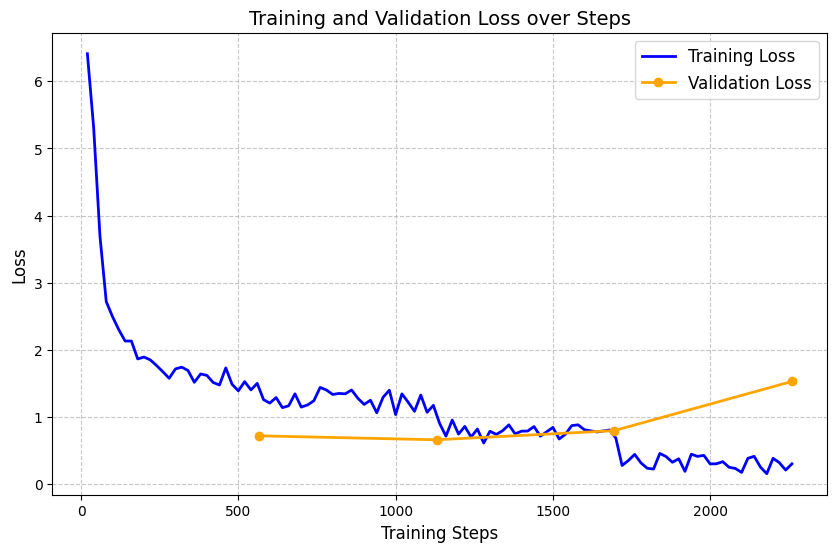

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = []
train_losses = []
eval_steps = []
eval_losses = []

for entry in log_history:
    if 'loss' in entry:
        train_steps.append(entry['step'])
        train_losses.append(entry['loss'])
    elif 'eval_loss' in entry:
        eval_steps.append(entry['step'])
        eval_losses.append(entry['eval_loss'])

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_losses, label='Training Loss', color='blue', linewidth=2)

if eval_steps:
    plt.plot(eval_steps, eval_losses, label='Validation Loss', color='orange', marker='o', linewidth=2)

plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss over Steps', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

In [15]:
import zipfile
import os

zip_path = "/content/qwen-3-1.7B-sentiment-adapter.zip"
extract_path = "/content/qwen-3-1.7B-sentiment-adapter"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [16]:
from peft import PeftModel

model = PeftModel.from_pretrained(
    model,
    "/content/qwen-3-1.7B-sentiment-adapter"
)

In [21]:
eval_dataloader = DataLoader(
    tokenized_datasets["test"],
    batch_size=8,
    collate_fn=data_collator
)

In [22]:
all_predictions = []
all_true_labels = []
all_probs = []

model.eval()

with torch.no_grad():
    for batch in tqdm(eval_dataloader, desc="Evaluating"):

        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['labels'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        probs = torch.softmax(logits, dim=-1)
        preds = torch.argmax(logits, dim=-1)

        all_predictions.extend(preds.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

Evaluating:   0%|          | 0/142 [00:00<?, ?it/s]

In [23]:
print("Predictions:", len(all_predictions))
print("True labels:", len(all_true_labels))
print("Probabilities:", len(all_probs))

Predictions: 1130
True labels: 1130
Probabilities: 1130


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import numpy as np

y_true = np.array(all_true_labels)
y_pred = np.array(all_predictions)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
roc_auc = roc_auc_score(y_true, np.array(all_probs), multi_class='ovr', average='weighted')


print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Accuracy  : 0.7000
Precision : 0.7003
Recall    : 0.7000
F1 Score  : 0.6998
ROC-AUC   : 0.8527


In [25]:
eval_df = pd.read_csv('/content/twitter_testing_3class.csv')

In [26]:
label_map = {0: "Other", 1: "Negative", 2: "Positive"}

results_df = pd.DataFrame({
    'tweet_text': eval_df['tweet'].tolist(),
    'true_label_num': all_true_labels,
    'predicted_label_num': all_predictions
})

errors_df = results_df[results_df['true_label_num'] != results_df['predicted_label_num']]

print(f"Total Evaluation Size: {len(results_df)}")
print(f"Total Errors Made: {len(errors_df)}")
print(f"Accuracy: {((len(results_df) - len(errors_df)) / len(results_df)) * 100:.2f}%\n")
print("="*50)
print("EXAMPLES OF INCORRECT PREDICTIONS ")
print("="*50)

for index, row in errors_df.head(20).iterrows():
    actual_str = label_map.get(row['true_label_num'], "Unknown")
    pred_str = label_map.get(row['predicted_label_num'], "Unknown")

    print(f"TEXT:     {row['tweet_text']}")
    print(f"ACTUAL:   {actual_str}")
    print(f"PREDICTED: {pred_str}")
    print("-" * 50)

Total Evaluation Size: 1130
Total Errors Made: 339
Accuracy: 70.00%

EXAMPLES OF INCORRECT PREDICTIONS 
TEXT:     just hanging out and playing hearthstone badly .
ACTUAL:   Positive
PREDICTED: Other
--------------------------------------------------
TEXT:     ok i am blocking this mans he is on a new level of being
ACTUAL:   Other
PREDICTED: Negative
--------------------------------------------------
TEXT:     need help with my game. for some reason my character is lagging no matter whose hose or solo and my game is up to date. and it is really frustrating any ideas would
ACTUAL:   Negative
PREDICTED: Other
--------------------------------------------------
TEXT:     the greatest shatter in overwatch pic.
ACTUAL:   Negative
PREDICTED: Positive
--------------------------------------------------
TEXT:     fall guys servers are on fire again let us switch to
ACTUAL:   Positive
PREDICTED: Other
--------------------------------------------------
TEXT:     thank you for bringing shipment twe

In [27]:
import torch.nn.functional as F

print("Running evaluation to capture all probabilities...")
model.eval()

all_predictions = []
all_true_labels = []
all_probabilities = []

with torch.no_grad():
    for batch in tqdm(eval_dataloader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['labels'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        probs = F.softmax(logits, dim=-1)

        predictions = torch.argmax(probs, dim=-1)

        all_predictions.extend(predictions.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probs.cpu().numpy())

label_map = {0: "Other", 1: "Negative", 2: "Positive"}


results_df = pd.DataFrame({
    'tweet_text': eval_df['tweet'].tolist(),
    'actual': [label_map.get(label, "Unknown") for label in all_true_labels],
    'predicted': [label_map.get(pred, "Unknown") for pred in all_predictions],
    'probs': all_probabilities # This holds [score_0, score_1, score_2, score_3]
})

errors_df = results_df[results_df['actual'] != results_df['predicted']]

print("\n" + "="*80)
print(" MISCLASSIFIED EXAMPLES WITH FULL CONFIDENCE SPREAD ")
print("="*80)

for index, row in errors_df.head(20).iterrows():
    p = row['probs']

    print(f"TEXT:       {row['tweet_text']}")
    print(f"ACTUAL:     {row['actual']}")
    print(f"PREDICTED:  {row['predicted']}")

    print("SCORES:     "
          f"Other: {p[0]:>6.2%} | "
          f"Negative: {p[1]:>6.2%} | "
          f"Positive: {p[2]:>6.2%} | ")
    print("-" * 80)

Running evaluation to capture all probabilities...


Evaluating:   0%|          | 0/142 [00:00<?, ?it/s]


 MISCLASSIFIED EXAMPLES WITH FULL CONFIDENCE SPREAD 
TEXT:       just hanging out and playing hearthstone badly .
ACTUAL:     Positive
PREDICTED:  Other
SCORES:     Other: 88.72% | Negative:  7.10% | Positive:  4.19% | 
--------------------------------------------------------------------------------
TEXT:       ok i am blocking this mans he is on a new level of being
ACTUAL:     Other
PREDICTED:  Negative
SCORES:     Other: 30.25% | Negative: 69.74% | Positive:  0.01% | 
--------------------------------------------------------------------------------
TEXT:       need help with my game. for some reason my character is lagging no matter whose hose or solo and my game is up to date. and it is really frustrating any ideas would
ACTUAL:     Negative
PREDICTED:  Other
SCORES:     Other: 74.13% | Negative:  1.68% | Positive: 24.20% | 
--------------------------------------------------------------------------------
TEXT:       the greatest shatter in overwatch pic.
ACTUAL:     Negative
PREDIC

In [28]:
pos_to_neg_errors = results_df[(results_df['actual'] == 'Positive') & (results_df['predicted'] == 'Negative')]

neg_to_pos_errors = results_df[(results_df['actual'] == 'Negative') & (results_df['predicted'] == 'Positive')]


def print_error_examples(df, title, num_examples=20):
    print("\n" + "="*80)
    print(f" {title} (Total found: {len(df)})")
    print("="*80)

    for index, row in df.head(num_examples).iterrows():
        p = row['probs']

        print(f"TEXT:       {row['tweet_text']}")
        print(f"ACTUAL:     {row['actual']}")
        print(f"PREDICTED:  {row['predicted']}")
        print("SCORES:     "
              f"Other: {p[0]:>6.2%} | "
              f"Negative: {p[1]:>6.2%} | "
              f"Positive: {p[2]:>6.2%} | ")
        print("-" * 80)

print_error_examples(pos_to_neg_errors, "ACTUAL: POSITIVE -> PREDICTED: NEGATIVE", 20)

print_error_examples(neg_to_pos_errors, "ACTUAL: NEGATIVE -> PREDICTED: POSITIVE", 20)


 ACTUAL: POSITIVE -> PREDICTED: NEGATIVE (Total found: 22)
TEXT:       are we going to simply pretend here that and not forget that they are making . you are move ubisoft we are waiting!
ACTUAL:     Positive
PREDICTED:  Negative
SCORES:     Other:  0.02% | Negative: 99.95% | Positive:  0.03% | 
--------------------------------------------------------------------------------
TEXT:       i just played black ops three omg. it is soo smooth!what has happened to call of duty!
ACTUAL:     Positive
PREDICTED:  Negative
SCORES:     Other:  0.08% | Negative: 99.64% | Positive:  0.29% | 
--------------------------------------------------------------------------------
TEXT:       what it say them graphics will compete with psfive. you see it. shit getting real t
ACTUAL:     Positive
PREDICTED:  Negative
SCORES:     Other: 34.73% | Negative: 65.00% | Positive:  0.27% | 
--------------------------------------------------------------------------------
TEXT:       i really do not know why i play for

In [29]:
other_to_neg_errors = results_df[(results_df['actual'] == 'Other') & (results_df['predicted'] == 'Negative')]

other_to_pos_errors = results_df[(results_df['actual'] == 'Other') & (results_df['predicted'] == 'Positive')]


def print_error_examples(df, title, num_examples=20):
    print("\n" + "="*80)
    print(f" {title} (Total found: {len(df)})")
    print("="*80)

    for index, row in df.head(num_examples).iterrows():
        p = row['probs']

        print(f"TEXT:       {row['tweet_text']}")
        print(f"ACTUAL:     {row['actual']}")
        print(f"PREDICTED:  {row['predicted']}")
        print("SCORES:     "
              f"Other: {p[0]:>6.2%} | "
              f"Negative: {p[1]:>6.2%} | "
              f"Positive: {p[2]:>6.2%} | ")
        print("-" * 80)

print_error_examples(other_to_neg_errors, "ACTUAL: Other -> PREDICTED: NEGATIVE", 20)

print_error_examples(other_to_pos_errors, "ACTUAL: Other -> PREDICTED: POSITIVE", 20)


 ACTUAL: Other -> PREDICTED: NEGATIVE (Total found: 79)
TEXT:       ok i am blocking this mans he is on a new level of being
ACTUAL:     Other
PREDICTED:  Negative
SCORES:     Other: 30.25% | Negative: 69.74% | Positive:  0.01% | 
--------------------------------------------------------------------------------
TEXT:       the corruption and knocking up of overwatch babes is a serious mood atm. pic.
ACTUAL:     Other
PREDICTED:  Negative
SCORES:     Other: 45.03% | Negative: 54.72% | Positive:  0.26% | 
--------------------------------------------------------------------------------
TEXT:       why the story mode is so limited. i just completed the game last night. everything is so perfect in this game but the story mode should be extended a bit pleading face
ACTUAL:     Other
PREDICTED:  Negative
SCORES:     Other:  9.48% | Negative: 89.77% | Positive:  0.76% | 
--------------------------------------------------------------------------------
TEXT:       someone hacked my uncles facebo

In [30]:
class_names = ["Other","Negative", "Positive"]

print("--- Classification Report ---")
report = classification_report(
    all_true_labels,
    all_predictions,
    target_names=class_names,
    digits=3
)
print(report)

--- Classification Report ---
              precision    recall  f1-score   support

       Other      0.678     0.691     0.685       473
    Negative      0.717     0.740     0.728       346
    Positive      0.715     0.669     0.691       311

    accuracy                          0.700      1130
   macro avg      0.703     0.700     0.701      1130
weighted avg      0.700     0.700     0.700      1130



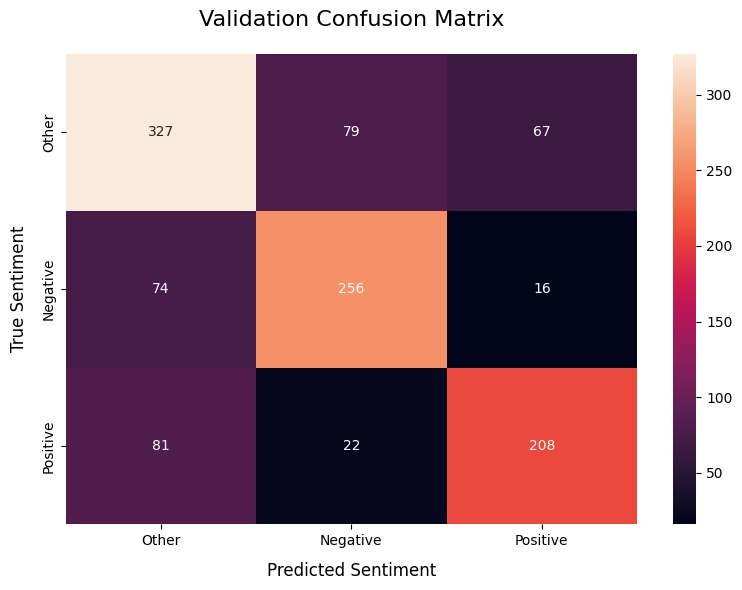

In [31]:
cm = confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True,fmt='d',   xticklabels=class_names, yticklabels=class_names)

plt.title('Validation Confusion Matrix', fontsize=16, pad=20)
plt.xlabel('Predicted Sentiment', fontsize=12, labelpad=10)
plt.ylabel('True Sentiment', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

In [ ]:
adapter_path = "/kaggle/working/qwen-3-1.7B-sentiment-adapter"

# Save only the LoRA weights and configuration
model.save_pretrained(adapter_path)

In [ ]:
import shutil

folder_path = "/kaggle/working/qwen-3-1.7B-sentiment-adapter"
zip_path = "/kaggle/working/qwen-3-1.7B-sentiment-adapter"

shutil.make_archive(zip_path.replace('.zip', ''), 'zip', folder_path)

print("Zipped successfully!")

Zipped successfully!
